In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
from sklearn.preprocessing import StandardScaler, RobustScaler
from scipy.stats.mstats import winsorize

In [24]:
df = pd.read_csv("pre_dataset_products.csv", index_col=0)

# Features para Clustering

In [27]:
# ── 1. FEATURES SELECCIONADAS ─────────────────────────────────────────────
# Eliminadas: taxonomy_score (casi constante), completeness_ratio y 
# compl_critical_ratio (poca varianza + alta correlación entre sí),
# unknown_ingredients_ratio (= -ingredients_quality_score),
# unique_scans_n (= scans_n), unknown_ingredients_n (correlada con ingredients_n)

features_num = [
    'ingredients_n',            # volumen de ingredientes (proxy de complejidad)
    'known_ingredients_n',      # calidad del etiquetado
    'completeness',             # completitud general
    'ingredients_quality_score',# calidad de ingredientes (sustituye unknown_ratio)
    'countries_count',          # alcance geográfico
    'categories_count',         # diversidad de categorías
    'scans_n',                  # popularidad/engagement
    'product_quality_score',    # score global
]

features_flag = [
    'is_duplicate_product_name',
    'ingredients_match',
    'missing_country_flag',
    'missing_category_flag',
    'missing_both_taxonomy_flag',
    'has_lang_conflict',
]

# ──> 2. WINSORIZING (recorte de outliers) en variables con outliers altos  - Recorta valores extremos que distorcionan el modelo
# ----------------------------------------
df_model = df.copy()

cols_to_winsorize = ['ingredients_n', 'known_ingredients_n', 
                      'scans_n', 'categories_count', 'countries_count']

for col in cols_to_winsorize:
    df_model[col] = winsorize(df_model[col], limits=[0, 0.01])  # recorta top 1%

# ──> 3. TRANSFORMACIÓN LOG en variables muy sesgadas, para comprimir la escala y hacer distribuciones simétrica 
# ----------------------------------------
cols_log = ['ingredients_n', 'known_ingredients_n', 'scans_n']

for col in cols_log:
    df_model[f'{col}_log'] = np.log1p(df_model[col])
    # reemplazamos la original
    df_model.drop(columns=[col], inplace=True)
    features_num = [f'{col}_log' if x == col else x for x in features_num]

# ──> 4. Escalado con RobustScaler 
# ----------------------------------------
# RobustScaler: mejor que StandardScaler cuando hay outliers residuales
scaler = RobustScaler()

X_num = scaler.fit_transform(df_model[features_num])
X_flag = df_model[features_flag].values.astype(float)

# Combinar
X = np.hstack([X_num, X_flag])

feature_names = features_num + features_flag
print(f"Shape del dataset para clustering: {X.shape}")
print(f"Features: {feature_names}")

# ──> 5. VERIFICACIÓN RÁPIDA DE VARIANZA 
# ----------------------------------------
variances = X.var(axis=0)
print("\n=== Varianza por feature (post-scaling) ===")
for name, var in sorted(zip(feature_names, variances), key=lambda x: x[1]):
    print(f"  {name}: {var:.3f}")


Shape del dataset para clustering: (14524, 14)
Features: ['ingredients_n_log', 'known_ingredients_n_log', 'completeness', 'ingredients_quality_score', 'countries_count', 'categories_count', 'scans_n_log', 'product_quality_score', 'is_duplicate_product_name', 'ingredients_match', 'missing_country_flag', 'missing_category_flag', 'missing_both_taxonomy_flag', 'has_lang_conflict']

=== Varianza por feature (post-scaling) ===
  missing_both_taxonomy_flag: 0.009
  missing_country_flag: 0.020
  has_lang_conflict: 0.100
  countries_count: 0.142
  is_duplicate_product_name: 0.157
  missing_category_flag: 0.196
  ingredients_match: 0.235
  categories_count: 0.258
  known_ingredients_n_log: 0.427
  ingredients_quality_score: 0.651
  completeness: 0.726
  product_quality_score: 0.832
  ingredients_n_log: 1.082
  scans_n_log: 1.650


# Determinando números de cluster

Probando k=2...
Probando k=3...
Probando k=4...
Probando k=5...
Probando k=6...
Probando k=7...
Probando k=8...
Probando k=9...
Probando k=10...


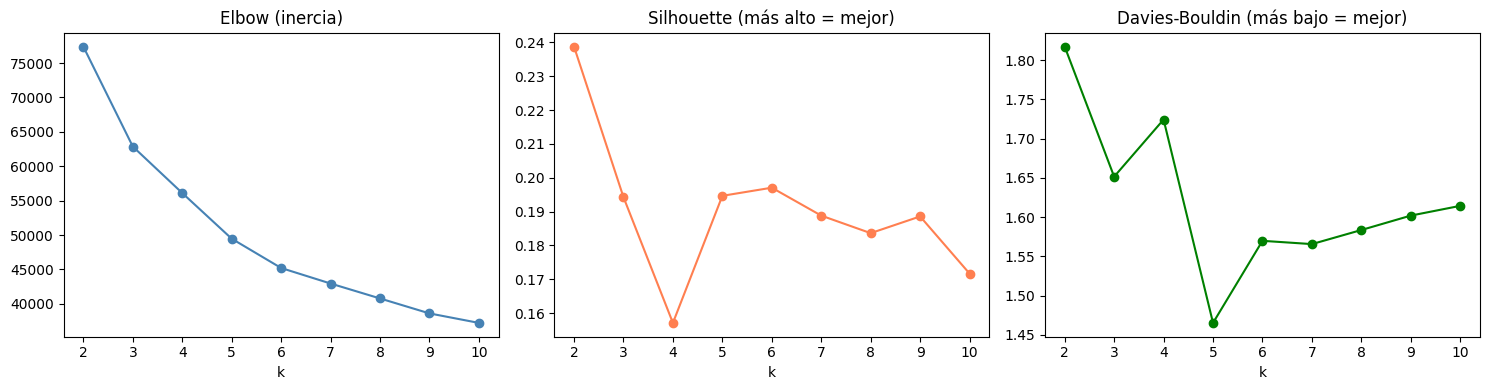


K sugerido por Silhouette: 2


In [30]:
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Elbow + Silhouette para k entre 2 y 10
inertias = []
silhouettes = []
db_scores = []
K_range = range(2, 11)

for k in K_range:
    print(f"Probando k={k}...")
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels, sample_size=3000))
    db_scores.append(davies_bouldin_score(X, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(K_range, inertias, 'o-', color='steelblue')
axes[0].set_title('Elbow (inercia)')
axes[0].set_xlabel('k')

axes[1].plot(K_range, silhouettes, 'o-', color='coral')
axes[1].set_title('Silhouette (más alto = mejor)')
axes[1].set_xlabel('k')

axes[2].plot(K_range, db_scores, 'o-', color='green')
axes[2].set_title('Davies-Bouldin (más bajo = mejor)')
axes[2].set_xlabel('k')

plt.tight_layout()
plt.show()

# El k óptimo es donde silhouette es máximo Y Davies-Bouldin es mínimo
best_k = K_range[silhouettes.index(max(silhouettes))]
print(f"\nK sugerido por Silhouette: {best_k}")

# Aplicacion del modelo

In [32]:
# Probar k=2 y k=5, ver qué tan interpretables son
for k in [2, 5]:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10)
    df_model[f'cluster_k{k}'] = km.fit_predict(X)

# ── Ver perfil de cada cluster ────────────────────────────────────────────
profile_cols = features_num + features_flag + ['product_quality_score', 'brand_group']

for k in [2, 5]:
    print(f"\n{'='*60}")
    print(f"PERFIL DE CLUSTERS con k={k}")
    print(f"{'='*60}")
    
    col = f'cluster_k{k}'
    
    # Tamaño de cada cluster
    print("\nTamaño:")
    print(df_model[col].value_counts().sort_index())
    
    # Mediana de variables numéricas por cluster
    print("\nMediana variables numéricas:")
    print(df_model.groupby(col)[features_num].median().round(2).T)
    
    # % de flags por cluster  
    print("\n% flags activos por cluster:")
    print((df_model.groupby(col)[features_flag].mean() * 100).round(1).T)
    
    # Brand group más frecuente por cluster
    print("\nBrand group más frecuente por cluster:")
    for cluster_id in sorted(df_model[col].unique()):
        top = df_model[df_model[col] == cluster_id]['brand_group'].value_counts().head(3)
        print(f"  Cluster {cluster_id}: {dict(top)}")


PERFIL DE CLUSTERS con k=2

Tamaño:
cluster_k2
0    10988
1     3536
Name: count, dtype: int64

Mediana variables numéricas:
cluster_k2                    0     1
ingredients_n_log          3.04  3.04
known_ingredients_n_log    1.79  2.64
completeness               0.46  0.57
ingredients_quality_score  0.24  0.70
countries_count            1.00  1.00
categories_count           2.00  2.00
scans_n_log                0.00  1.39
product_quality_score      0.71  0.87

% flags activos por cluster:
cluster_k2                     0     1
is_duplicate_product_name   17.9  24.8
ingredients_match           57.5  76.3
missing_country_flag         2.2   1.4
missing_category_flag       29.7  17.4
missing_both_taxonomy_flag   1.1   0.3
has_lang_conflict           11.4  10.8

Brand group más frecuente por cluster:
  Cluster 0: {'Other': np.int64(5114), 'Unknown': np.int64(2189), "L'Oréal": np.int64(643)}
  Cluster 1: {'Other': np.int64(1713), 'Unknown': np.int64(342), "L'Oréal": np.int64(165)}

PERFI

Varianza explicada por PCA: 29.2% + 25.4% = 54.7%


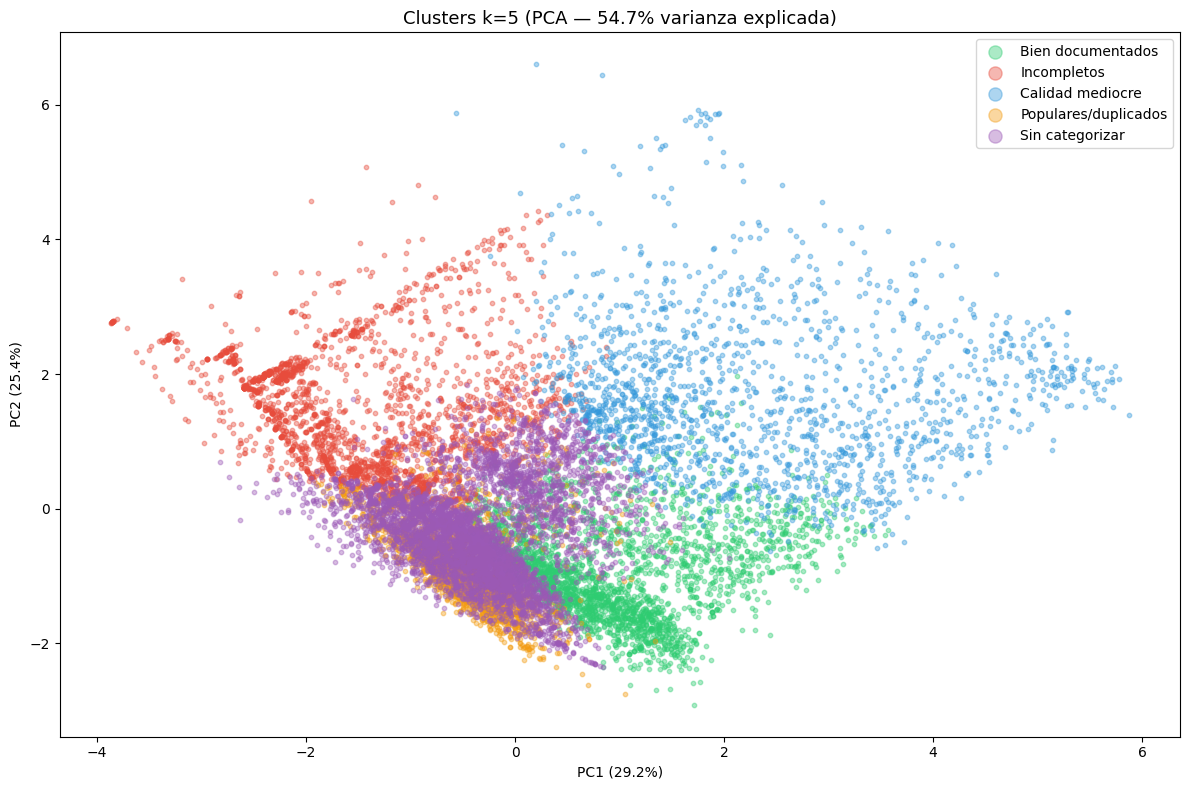

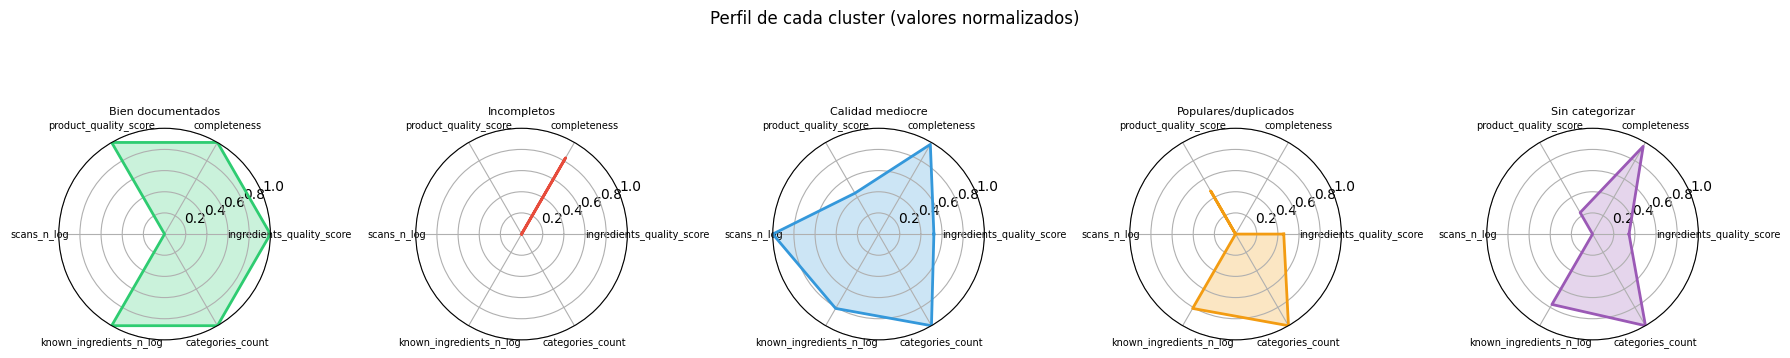


=== Distribución final ===
cluster_name
Sin categorizar         5196
Bien documentados       2605
Incompletos             2543
Populares/duplicados    2469
Calidad mediocre        1711
Name: count, dtype: int64


In [33]:
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

# ── PCA para visualizar en 2D ─────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

explained = pca.explained_variance_ratio_
print(f"Varianza explicada por PCA: {explained[0]:.1%} + {explained[1]:.1%} = {sum(explained):.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────
cluster_names = {
    0: "Bien documentados",
    1: "Incompletos",
    2: "Calidad mediocre",
    3: "Populares/duplicados",
    4: "Sin categorizar"
}

colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(12, 8))

for k in range(5):
    mask = df_model['cluster_k5'] == k
    ax.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=colors[k], label=cluster_names[k],
        alpha=0.4, s=10, rasterized=True
    )

ax.set_title(f'Clusters k=5 (PCA — {sum(explained):.1%} varianza explicada)', fontsize=13)
ax.set_xlabel(f'PC1 ({explained[0]:.1%})')
ax.set_ylabel(f'PC2 ({explained[1]:.1%})')
ax.legend(markerscale=3, fontsize=10)
plt.tight_layout()
plt.show()

# ── Radar chart por cluster ───────────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch

# Normalizar medianas para el radar
radar_features = [
    'ingredients_quality_score', 'completeness',
    'product_quality_score', 'scans_n_log',
    'known_ingredients_n_log', 'categories_count'
]

medians = df_model.groupby('cluster_k5')[radar_features].median()
# Normalizar 0-1
medians_norm = (medians - medians.min()) / (medians.max() - medians.min() + 1e-9)

N = len(radar_features)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 5, figsize=(18, 4), subplot_kw=dict(polar=True))

for i, (cluster_id, row) in enumerate(medians_norm.iterrows()):
    values = row.tolist() + [row.tolist()[0]]
    axes[i].plot(angles, values, color=colors[i], linewidth=2)
    axes[i].fill(angles, values, color=colors[i], alpha=0.25)
    axes[i].set_xticks(angles[:-1])
    axes[i].set_xticklabels(radar_features, size=7)
    axes[i].set_title(cluster_names[cluster_id], size=8, pad=10)
    axes[i].set_ylim(0, 1)

plt.suptitle('Perfil de cada cluster (valores normalizados)', y=1.02)
plt.tight_layout()
plt.show()

# ── Guardar el cluster en el df original ─────────────────────────────────
df['cluster'] = df_model['cluster_k5']
df['cluster_name'] = df['cluster'].map(cluster_names)

print("\n=== Distribución final ===")
print(df['cluster_name'].value_counts())

In [34]:
# ¿Qué son realmente los productos del cluster 1 (Incompletos)?
c1 = df[df['cluster'] == 1][['product_name', 'brand_group', 
                               'completeness', 'ingredients_n',
                               'product_quality_score', 
                               'missing_category_flag']].head(20)
print("Cluster 1")
print(c1.to_string())

# ¿Y los populares/duplicados (cluster 3)?
c3 = df[df['cluster'] == 3][['product_name', 'brand_group',
                               'scans_n', 'is_duplicate_product_name',
                               'product_quality_score']].head(20)
print("\n\nCluster 3")
print(c3.to_string())

# Resumen ejecutivo final
print("\n=== RESUMEN EJECUTIVO ===")
summary = df.groupby('cluster_name').agg(
    n_productos=('product_name', 'count'),
    quality_media=('product_quality_score', 'mean'),
    pct_duplicados=('is_duplicate_product_name', 'mean'),
    pct_sin_categoria=('missing_category_flag', 'mean'),
    pct_ingredientes_ok=('ingredients_match', 'mean'),
    scans_mediana=('scans_n', 'median')
).round(2)

summary['quality_media'] = summary['quality_media'].round(3)
summary['pct_duplicados'] = (summary['pct_duplicados'] * 100).round(1)
summary['pct_sin_categoria'] = (summary['pct_sin_categoria'] * 100).round(1)
summary['pct_ingredientes_ok'] = (summary['pct_ingredientes_ok'] * 100).round(1)

print(summary.to_string())

Cluster 1
                                                      product_name         brand_group  completeness  ingredients_n  product_quality_score  missing_category_flag
1454                                                Pasta dentária                Lidl        0.3625              1               0.650000                      1
1663                                       Saundarya aloe vera gel               Other        0.5750              1               0.650000                      0
1803                            Skin Active agua micelar en aceite   Garnier (L'Oréal)        0.4750              1               0.650000                      0
1815                                          savon pour les mains             Unknown        0.3750              2               0.650000                      0
1888                                               No Product Name             Unknown        0.1875              5               0.242857                      1
1980              

# Clasificador

In [35]:
df_model.to_csv("final_dataset.csv")

                      precision    recall  f1-score   support

   Bien documentados       0.99      0.98      0.98       521
         Incompletos       0.98      0.97      0.98       509
    Calidad mediocre       0.98      0.97      0.98       342
Populares/duplicados       0.99      0.96      0.98       494
     Sin categorizar       0.96      0.98      0.97      1039

            accuracy                           0.98      2905
           macro avg       0.98      0.97      0.98      2905
        weighted avg       0.98      0.98      0.98      2905



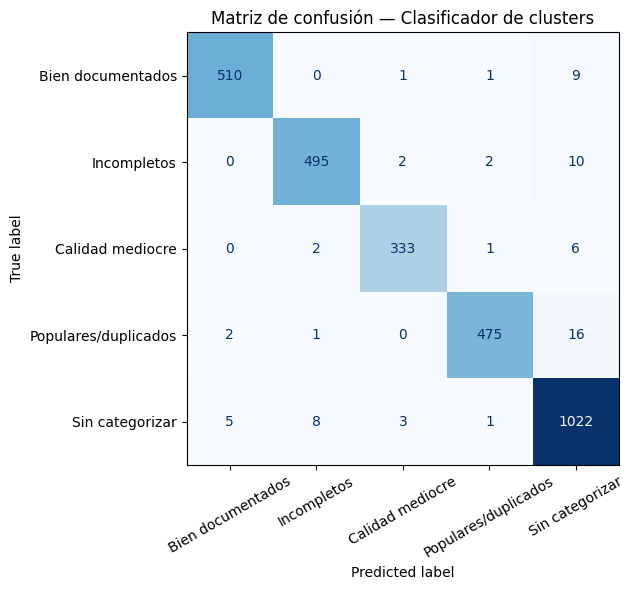

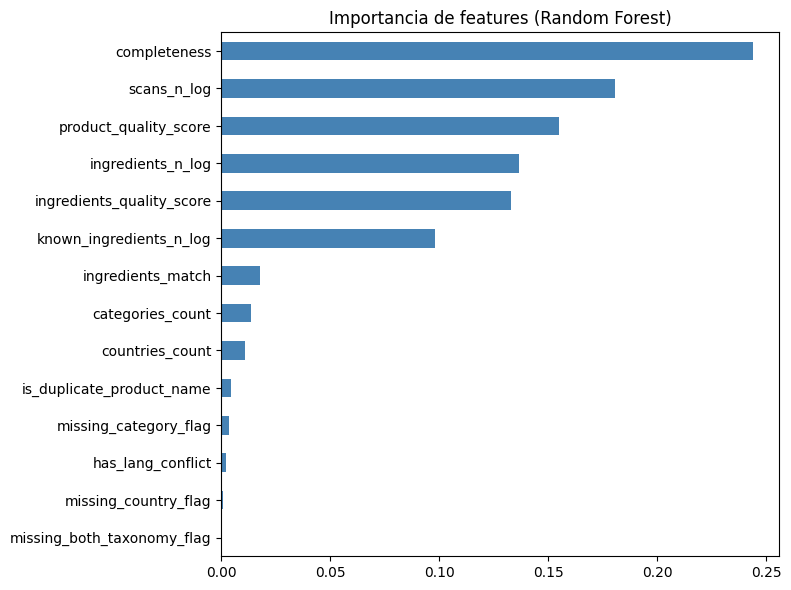

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# ──> Target: el cluster 
y = df_model['cluster_k5']
X_clf = X  # mismas features que usamos para clustering

# ──> Split 
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y, test_size=0.2, random_state=42, stratify=y
)

# ──> Modelo 
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# ──> Evaluación 
cluster_names_list = [
    "Bien documentados", "Incompletos", "Calidad mediocre",
    "Populares/duplicados", "Sin categorizar"
]

print(classification_report(y_test, y_pred, target_names=cluster_names_list))

# ──> Matriz de confusión 
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=cluster_names_list,
    ax=ax, colorbar=False, cmap='Blues',
    xticks_rotation=30
)
plt.title('Matriz de confusión — Clasificador de clusters')
plt.tight_layout()
plt.show()

# ──>  Feature importance 
importances = pd.Series(rf.feature_importances_, index=feature_names)
importances.sort_values().plot(
    kind='barh', figsize=(8, 6), color='steelblue',
    title='Importancia de features (Random Forest)'
)
plt.tight_layout()
plt.show()